In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("muhammadsaoodsarwar/drone-vs-bird")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 1.59G/1.59G [00:16<00:00, 103MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/muhammadsaoodsarwar/drone-vs-bird/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/muhammadsaoodsarwar/drone-vs-bird/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/muhammadsaoodsarwar/drone-vs-bird/versions/1):
['dataset']


In [ ]:
import os

# Explore the structure inside the drone-vs-bird dataset
# The previous cell showed the contents of 'path' is ['dataset']
drone_dataset_path = os.path.join(path, 'dataset')

if os.path.exists(drone_dataset_path):
    print(f"Subdirectories in drone dataset: {os.listdir(drone_dataset_path)}")
else:
    print(f"Directory {drone_dataset_path} does not exist. Please check the file structure.")

Subdirectories in drone dataset: ['bird', 'drone']


Found 4104 images. Displaying 6 sample images:


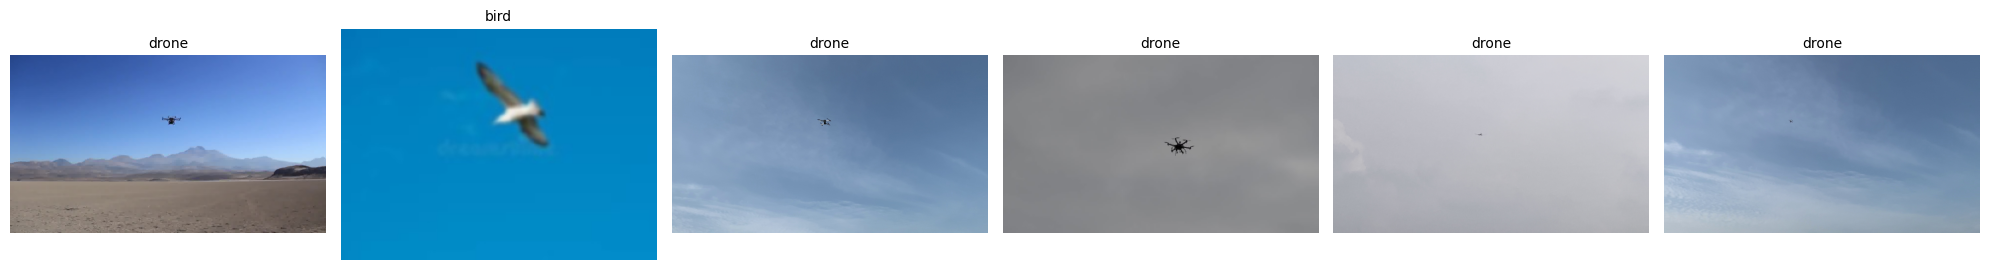

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1: axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(label, fontsize=10)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the path defined in cell 2 for the drone dataset
drone_dataset_path = os.path.join(path, 'dataset')
display_sample_images(drone_dataset_path)

In [ ]:
!pip install split-folders

In [ ]:
import os
# Ensure the library is available in the current environment
!pip install split-folders

import splitfolders

# Input folder from the drone-vs-bird dataset
input_folder = os.path.join(path, 'dataset')
output_folder = '/content/drone_bird_split'

# Create output directory if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Split data: train=0.8, val=0.2
if os.path.exists(input_folder):
    print(f"Splitting files from {input_folder} to {output_folder}...")
    splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.8, .2), group_prefix=None, move=False)
    print(f"Data successfully split into: {output_folder}")
    print(f"Subdirectories created: {os.listdir(output_folder)}")
else:
    print(f"Error: Input directory {input_folder} not found.")

Splitting files from /root/.cache/kagglehub/datasets/muhammadsaoodsarwar/drone-vs-bird/versions/1/dataset to /content/drone_bird_split...


Copying files: 4106 files [00:09, 456.07 files/s]

Data successfully split into: /content/drone_bird_split
Subdirectories created: ['val', 'train']


In [ ]:
def count_files(directory):
    return sum([len(files) for r, d, files in os.walk(directory)])

train_dir = os.path.join(output_folder, 'train')
val_dir = os.path.join(output_folder, 'val')

train_count = count_files(train_dir)
val_count = count_files(val_dir)
total = train_count + val_count

print(f"Dataset Split Statistics:")
print(f"- Train Set: {train_count} images ({train_count/total*100:.1f}%)")
print(f"- Val (Test) Set: {val_count} images ({val_count/total*100:.1f}%)")
print(f"- Total: {total} images")

Dataset Split Statistics:
- Train Set: 3284 images (80.0%)
- Val (Test) Set: 822 images (20.0%)
- Total: 4106 images


In [ ]:
import tensorflow as tf

# Check if GPU is available
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Training will be slow on CPU.')
else:
  print('Found GPU at: {}'.format(device_name))

Num GPUs Available:  1
Found GPU at: /device:GPU:0


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models, optimizers

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

# Data Augmentation and Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# Build DenseNet Model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers initially

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

Found 3282 images belonging to 2 classes.
Found 822 images belonging to 2 classes.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.7690 - loss: 0.4716 - val_accuracy: 0.9136 - val_loss: 0.2464
Epoch 2/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 90s 876ms/step - accuracy: 0.9116 - loss: 0.2400 - val_accuracy: 0.9562 - val_loss: 0.1581
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 90s 871ms/step - accuracy: 0.9372 - loss: 0.1754 - val_accuracy: 0.9672 - val_loss: 0.1197
Epoch 4/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 89s 862ms/step - accuracy: 0.9512 - loss: 0.1428 - val_accuracy: 0.9708 - val_loss: 0.1043
Epoch 5/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 89s 863ms/step - accuracy: 0.9531 - loss: 0.1306 - val_accuracy: 0.9757 - val_loss: 0.0875
Epoch 6/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 89s 865ms/step - accuracy: 0.9656 - loss: 0.1080 - val_accuracy: 0.9793 - val_loss: 0.0794
Epoch 7/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 90s 872ms/step - accuracy: 0.9640 - loss: 

In [ ]:
# Evaluate the model on the validation set
val_loss, val_acc = model.evaluate(val_generator)
print(f"Final Validation Loss: {val_loss:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 507ms/step - accuracy: 0.9830 - loss: 0.0624
Final Validation Loss: 0.0624
Final Validation Accuracy: 0.9830


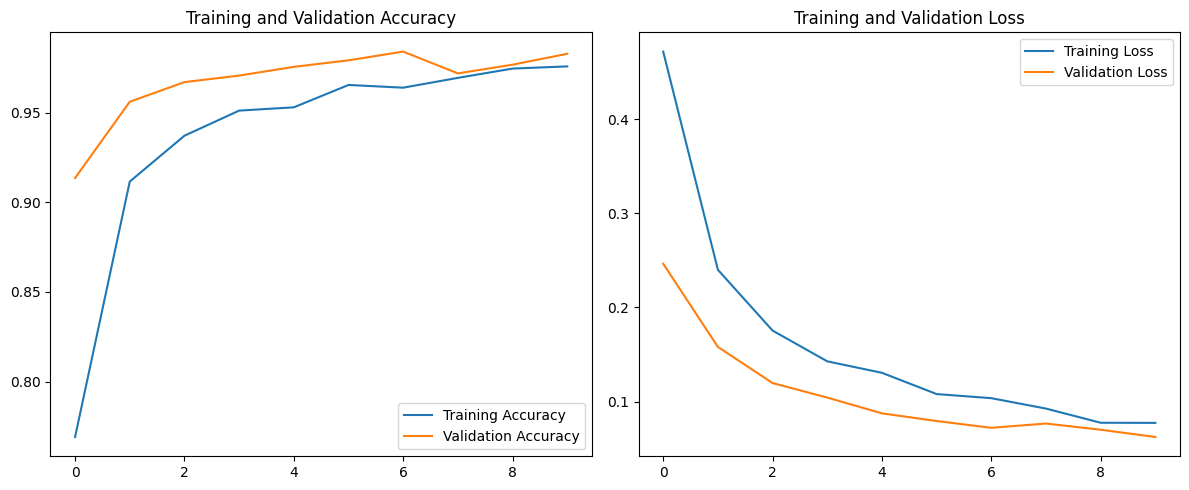

In [ ]:
import matplotlib.pyplot as plt

# Plot Training and Validation metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()